In [1]:
# Instalar PySpark en Google Colab
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.2-py2.py3-none-any.whl size=317812365 sha256=ab0982a6f9991eb979e1da5e7df55c4c6894e50563e2b652d3d294d3bc5e6087
  Stored in directory: /root/.cache/pip/wheels/34/34/bd/03944534c44b677cd5859f248090daa9fb27b3c8f8e5f49574
Successfully built pyspark


In [11]:
# librerias
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, sum, count, median, when, variance  # Importar funciones para operaciones en DataFrame
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Crear una SparkSession
spark = SparkSession.builder.appName("termografia").getOrCreate()

# Cargar el archivo CSV en un DataFrame de PySpark
file_path = "heart.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

# Mostrar las primeras filas del DataFrame
df.show()


+---+---+---+------+----+---+-------+--------+----+-------+---+---+-----+------+
|age|sex| cp|trtbps|chol|fbs|restecg|thalachh|exng|oldpeak|slp|caa|thall|output|
+---+---+---+------+----+---+-------+--------+----+-------+---+---+-----+------+
| 63|  1|  3|   145| 233|  1|      0|     150|   0|    2.3|  0|  0|    1|     1|
| 37|  1|  2|   130| 250|  0|      1|     187|   0|    3.5|  0|  0|    2|     1|
| 41|  0|  1|   130| 204|  0|      0|     172|   0|    1.4|  2|  0|    2|     1|
| 56|  1|  1|   120| 236|  0|      1|     178|   0|    0.8|  2|  0|    2|     1|
| 57|  0|  0|   120| 354|  0|      1|     163|   1|    0.6|  2|  0|    2|     1|
| 57|  1|  0|   140| 192|  0|      1|     148|   0|    0.4|  1|  0|    1|     1|
| 56|  0|  1|   140| 294|  0|      0|     153|   0|    1.3|  1|  0|    2|     1|
| 44|  1|  1|   120| 263|  0|      1|     173|   0|    0.0|  2|  0|    3|     1|
| 52|  1|  2|   172| 199|  1|      1|     162|   0|    0.5|  2|  0|    3|     1|
| 57|  1|  2|   150| 168|  0

In [7]:
#  Análisis Estadístico Descriptivo
df.describe().show()


+-------+------------------+-------------------+------------------+------------------+------------------+-------------------+-----------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|summary|               age|                sex|                cp|            trtbps|              chol|                fbs|          restecg|          thalachh|               exng|           oldpeak|               slp|               caa|             thall|            output|
+-------+------------------+-------------------+------------------+------------------+------------------+-------------------+-----------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|  count|               303|                303|               303|               303|               303|                303|              303|               303|    

In [12]:
#Ejemplo: Filtrar registros en función de ciertos criterios
filtered_df = df.filter(col("age") > 50)

# Calcular estadísticas descriptivas
stats = filtered_df.describe().toPandas()  # Calcular estadísticas y convertirlas a DataFrame de Pandas
average_chol = float(stats.loc[1, "chol"])  # Media de colesterol
median_chol = float(filtered_df.select(median("chol")).first()[0])  # Mediana de colesterol

# Imprimir los resultados
print(f"Media de colesterol: {average_chol}")
print(f"Mediana de colesterol: {median_chol}")

Media de colesterol: 252.84615384615384
Mediana de colesterol: 246.0


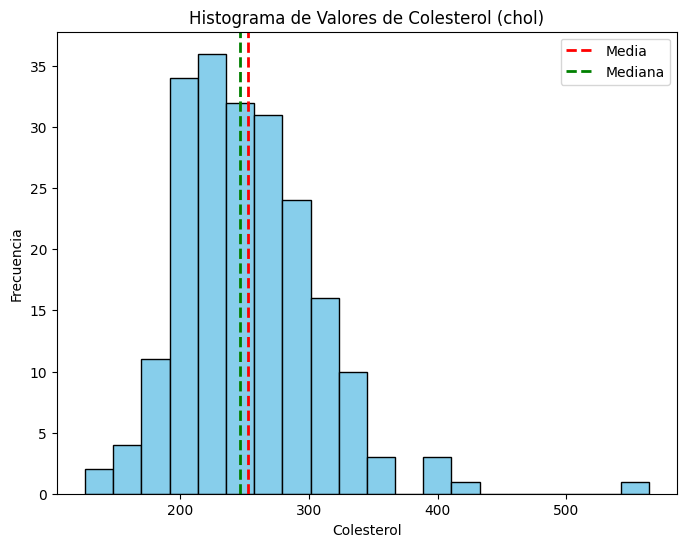

In [14]:
# Visualización
chol_values = filtered_df.select("chol").rdd.flatMap(lambda x: x).collect()

# Crear el histograma
plt.figure(figsize=(8, 6))
plt.hist(chol_values, bins=20, color='skyblue', edgecolor='black')
plt.title("Histograma de Valores de Colesterol (chol)")
plt.xlabel("Colesterol")
plt.ylabel("Frecuencia")
plt.axvline(average_chol, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_chol, color='green', linestyle='dashed', linewidth=2, label='Mediana')
plt.legend()
plt.show()

La distribución es aproximadamente simétrica, aunque parece ligeramente sesgada hacia la derecha (cola más larga en los valores más altos).
Hay un pico en la distribución alrededor de los 200-220, lo que indica que muchos individuos tienen valores de colesterol en este rango.
